In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [62]:
dataset = pd.read_csv("experiments/babyLFM5k/input/dataset.inter", sep="\t", header=0)
accepted_songs = pd.read_csv("experiments/babyLFM5k/output/iteration_10_accepted_songs.tsv", sep="\t", header=0)

In [63]:
tracks=pd.read_csv("experiments/babyLFM5k/input/tracks.tsv", sep="\t", header=None,names=["track_id","artist","title","country","gender"])

In [64]:
# Count song popularity in train data and recommendations
train_counts = dataset["item_id:token"].value_counts()
rec_counts = accepted_songs["item_id:token"].value_counts()

# Combine into one dataframe
popularity = (
    pd.DataFrame({
        "train_popularity": train_counts,
        "recommendation_popularity": rec_counts
    })
    .fillna(0)
    .astype(int)
)

# Sort by train popularity
popularity = popularity.sort_values("train_popularity", ascending=False)

# Optional: plot only top N most popular train songs
top_n = 50
plot_df = popularity.head(top_n)


In [65]:


# Make sure IDs have the same dtype
tracks["track_id"] = tracks["track_id"].astype(str)
popularity_plot = popularity.copy()
popularity_plot.index = popularity_plot.index.astype(str)

# Add gender info to popularity dataframe
popularity_plot = popularity_plot.merge(
    tracks[["track_id", "gender"]],
    left_index=True,
    right_on="track_id",
    how="left"
)

# Optional: handle missing gender
popularity_plot["gender"] = popularity_plot["gender"].fillna("unknown")

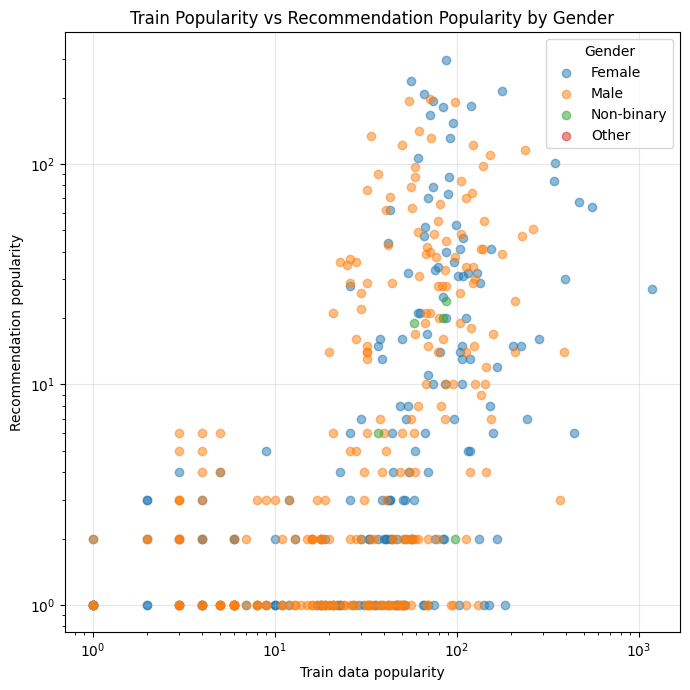

In [66]:


plt.figure(figsize=(7, 7))

for gender, group in popularity_plot.groupby("gender"):
    plt.scatter(
        group["train_popularity"],
        group["recommendation_popularity"],
        alpha=0.5,
        label=gender
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Train data popularity")
plt.ylabel("Recommendation popularity")
plt.title("Train Popularity vs Recommendation Popularity by Gender")
plt.legend(title="Gender")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [67]:
popularity_plot[popularity_plot["gender"]=="Female"]["recommendation_popularity"].sum()/popularity_plot["recommendation_popularity"].sum()

0.46859410430839005

In [68]:
popularity_plot[popularity_plot["gender"]=="Male"]["recommendation_popularity"].sum()/popularity_plot["recommendation_popularity"].sum()

0.5233560090702948

In [69]:
np.mean(tracks.iloc[dataset["item_id:token"]]["gender"]=="Female")

0.4002239218309245

In [70]:
np.mean(tracks.iloc[dataset["item_id:token"]]["gender"]=="Male")

0.5850175938581441

In [71]:
np.mean(popularity_plot["gender"] == "Female")

0.41633306645316254

In [72]:
np.mean(popularity_plot["gender"] == "Male")

0.5714571657325861